In [7]:
import os
import sys
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path

# Walk up from cwd until src/mt2d_inv is found (works under tests/*)
_project_root = None
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "mt2d_inv").is_dir():
        _project_root = str(_p)
        break
if _project_root is None:
    raise RuntimeError("Could not find MTinv_OT project root (src/mt2d_inv)")
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.mt2d_inv import MT2DInverterWeightedCost
from src.mt2d_inv.io import ExperimentLogger

logger = ExperimentLogger(
    model_tag="AKBST-AMT-L08",
    output_root=Path("test_results"),
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


Device: cpu


In [8]:
# ============================================================
# 0) 全局画图参数（统一管理，一改全改）
# ============================================================
PLOT_CONFIG = {
    "mc_cmap": "jet_r",
    "mc_clip_to_stations": True,
    "mc_ylim": [10, 0],
    "mc_profile_extend_km": 5.0,
    "mc_profile_axis_width_km": 45.0,
    "mc_vmin": 0.0,
    "mc_vmax": 4.0,
    "mc_axes_aspect": 1.07,
    "im_cmap": "jet_r",
    "im_clip_to_stations": True,
    "im_ylim": [10, 0],
    "im_profile_extend_km": 5.0,
    "im_profile_axis_width_km": 50.0,
    "df_station_indices": "all",
    "df_plot_noise_cap": None,
    "pf_depth_limit_km": 10,
}

save_plot_kwargs = PLOT_CONFIG


In [9]:
from __future__ import annotations

from src.mt2d_inv.data_prep import PrepareData

# ================= USER PARAMETERS =================
EDI_DIR = "AKBST-AMT-L08"
FREQ_MIN_HZ = 1
FREQ_MAX_HZ = 1000
MAG_DECLINATION_DEG = 4
# ===================================================

prep = PrepareData(
    edi_dir=EDI_DIR,
    n_freq_target=20,
    mag_declination_deg=MAG_DECLINATION_DEG,
    edi_impedance_unit="mv/km/nt",
    freq_min_hz=FREQ_MIN_HZ,
    freq_max_hz=FREQ_MAX_HZ,
)

prep.run_all_simple()


Using EDI_DIR = AKBST-AMT-L08
Found 28 EDI files
[PrepareData] Converted impedance units to ohms for 28/28 stations (edi_impedance_unit='mv/km/nt').
[PrepareData] Data cleaning (OOQ + rel_err + skew + neighbor-spike): OOQ Zxy=0, OOQ Zyx=4, rel_err>50%=6, |skew|>8.0°=62, neighbor-spike(z>4.0, rho_log10>0.25, phs>8.0°)=(Zxy:4, Zyx:6) pts set to NaN
[PrepareData] Skipped frequency harmonization. Stations retain their original frequencies.
[PrepareData] WARNING: n_freq_target=20 is ignored because harmonize_freqs=False. Downsampling requires an aligned frequency grid in the current implementation.
Estimated regional strike (magnetic reference) = 49.76150262903805
Magnetic declination (manual, east positive) = 4.000 deg
Estimated regional strike (true north reference) = 53.761502629038034
All stations rotated by 49.76 degrees
[PrepareData] Exported Tensor shape: Frequencies=39, Stations=28


(tensor([  1.1878,   1.4144,   1.6842,   2.0054,   2.3879,   2.8433,   3.3856,
           4.0313,   4.8002,   5.7158,   6.8060,   8.1040,   9.6497,  11.4902,
          13.6817,  16.2912,  19.3984,  23.0983,  27.5038,  32.7495,  38.9958,
          46.4335,  55.2897,  65.8350,  78.3917,  93.3433, 111.1470, 132.3450,
         157.5880, 187.6440, 223.4330, 266.0490, 316.7920, 377.2130, 449.1590,
         534.8260, 636.8330, 758.2960, 902.9250]),
 tensor([-18267.8155, -17383.4204, -16829.7381, -15403.5468, -14405.2632,
         -12638.9328, -11689.1563, -10603.6975,  -9607.8736,  -8612.0497,
          -6666.4494,  -3678.9778,  -2593.5189,   -647.9185,    393.9527,
           1387.3168,   3335.3770,   4438.6434,   5188.8826,   7182.9901,
           8447.7189,  10257.6369,  13472.8856,  14468.7095,  15280.3439,
          16232.5801,  17271.9916,  18267.8155]),
 {'obs_data': {'rhoxy': tensor([[2017.1786,  446.4686,  552.0493,  ..., 1574.8451,  386.0036,
             330.6805],
           [2122

In [10]:
# 1. 垂向网格
nza = 10
z_air = -np.logspace(np.log10(10), np.log10(50000), nza)
z_air = np.flip(z_air)
z_air = np.append(z_air, 0)

nz = 70
z_sub = np.logspace(np.log10(5), np.log10(25000), nz)
zn = np.concatenate([z_air[:-1], np.array([0]), z_sub])

# 2. 横向网格
y_center = np.linspace(-25000, 25000, 231)
y_left = -np.logspace(np.log10(25500), np.log10(70000), 20)
y_right = np.logspace(np.log10(25500), np.log10(70000), 20)
y_left = np.flip(y_left)
yn = np.concatenate([y_left, y_center, y_right])

print("新的网格统计:")
print(f" - 垂向第一层厚度: {zn[nza+1] - zn[nza]:.1f} m")
print(f" - 最大深度: {zn[-1]/1000:.1f} km")
print(f" - 中心区横向分辨率: {y_center[1] - y_center[0]:.1f} m")
print(f" - 网格总数: {len(zn)-1} x {len(yn)-1}")


新的网格统计:
 - 垂向第一层厚度: 5.0 m
 - 最大深度: 25.0 km
 - 中心区横向分辨率: 217.4 m
 - 网格总数: 80 x 270


In [ ]:
freqs_t, stations_t, data_dict = prep.export_data_dict_for_2d_inversion(device=device)

inv = MT2DInverterWeightedCost(
    yn=torch.as_tensor(yn, dtype=torch.float64, device=device),
    zn=torch.as_tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs_t,
    stations=stations_t,
    device=device,
    data_loss_scale=200,
)
inv.load_obs_data(data_dict, noise_floor=0.05)

w_d_point = inv.update_ot_w_d_per_point_from_noise(
    w_d_scale=[5, 1, 1, 1],
    normalize="mean",
)
print("per-point w_d:", tuple(w_d_point.shape), "mean per dim:", w_d_point.mean(dim=0).detach().cpu().numpy())


[PrepareData] Exported Tensor shape: Frequencies=39, Stations=28
✓ Random seed set: 42
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0818
   phi(normalized) noise mean: 0.0795
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0823
   phi(normalized) noise mean: 0.0799
✓ 2D data error propagation completed
Computing data weights (Target Noise: 5.0%)
  - Resistivity Error Floor: 5.0%
  - Phase Error Floor:       1.430 deg
✓ MSE data weights normalized (mean): scale=2.064829e+01
✓ Observed data loaded from file
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=tensor(1012, 4)@cpu, blur=0.0100, scale=0.9, reach=None
per-point w_d: (1012, 4) mean per dim: [5. 1. 1. 1.]


: 

✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m

OT dimension contributions (same-(f,s) matching)
--------------------------------------------------------------------------------------
dim name                  E[(Δx_k)^2]        w_k            w_k*E
--------------------------------------------------------------------------------------
0   freq(norm)           0.000000e+00     1.0000     0.000000e+00
    range pred=[0.0000, 1.0000]  obs=[0.0000, 1.0000]
1   station(norm)        0.000000e+00     1.0000     0.000000e+00
    range pred=[0.0000, 1.0000]  obs=[0.0000, 1.0000]
2   rhoxy                5.791190e-03     5.0000     2.895595e-02
    range pred=[0.5872, 0.5873]  obs=[0.3915, 0.7749]
3   phsxy                1.117383e-02     1.0000     1.117383e-02
    range pred=[0.5000, 0.5001]  obs=[0.1834, 0.7897]
4   rhoyx                7.778790e-03     1.0000     7.778790e-03
    range pred=[0.5868, 0.5875]  obs=[0.4376, 0.8117]
5   phsyx       

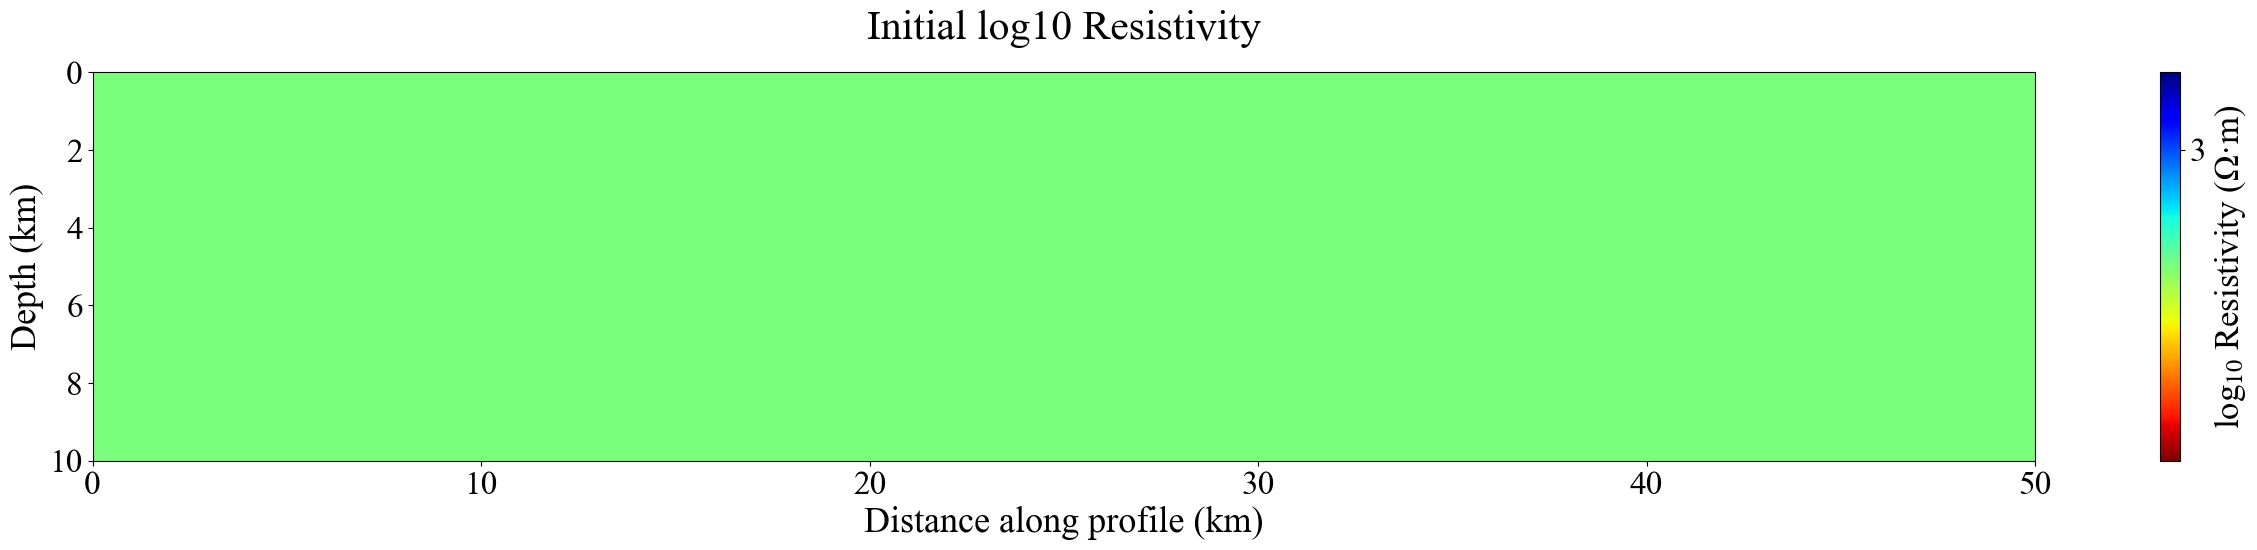

✓ Optimizer: AdamW, lr=0.05, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.05, weight_decay=0.0


In [ ]:
inv.set_forward_operator()
inv.initialize_model(initial_sigma=0.002)
inv.print_ot_dimension_contributions()

inv.plot_initial_model(
    clip_to_stations=PLOT_CONFIG["im_clip_to_stations"],
    ylim=PLOT_CONFIG["im_ylim"],
    profile_extend_km=PLOT_CONFIG["im_profile_extend_km"],
    profile_axis_width_km=PLOT_CONFIG["im_profile_axis_width_km"],
)

final_sigma = inv.run_inversion(
    n_epochs=3,
    mode="mse",
    progress_interval=10,
    current_lambda=1,
    use_adaptive_lambda=True,
    lr=0.05,
    update_interval=20,
    norm_type="L2",
    alpha=0.8,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    enable_blur_anneal=True,
)

print("反演完成，最终模型范围:")
print(final_sigma.min().item(), final_sigma.max().item())


In [ ]:
inv.plot_loss_history()

inv.plot_model_comparison(
    cmap=PLOT_CONFIG["mc_cmap"],
    clip_to_stations=PLOT_CONFIG["mc_clip_to_stations"],
    ylim=PLOT_CONFIG["mc_ylim"],
    profile_extend_km=PLOT_CONFIG["mc_profile_extend_km"],
    profile_axis_width_km=PLOT_CONFIG["mc_profile_axis_width_km"],
    vmin=PLOT_CONFIG["mc_vmin"],
    vmax=PLOT_CONFIG["mc_vmax"],
    axes_aspect=PLOT_CONFIG["mc_axes_aspect"],
)

print(freqs_t.min().item(), freqs_t.max().item())
batch_size = 3
n_stations = len(inv.stations)
for start in range(0, n_stations, batch_size):
    end = min(start + batch_size, n_stations)
    station_indices = list(range(start, end))
    inv.plot_data_fitting(station_indices=station_indices)
inv.plot_1d_profiles(depth_limit_km=PLOT_CONFIG["pf_depth_limit_km"])
inv.plot_gradient_history()


In [ ]:
logger.save_from_inverter(
    inv,
    run_name="mse",
    plot_kwargs=save_plot_kwargs,
)
